<a href="https://colab.research.google.com/github/hardikjadon/Alzymer-detection-model-using-MRI/blob/main/Alzymer_detection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from  google.colab import files
uploded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
!unzip "archive (1).zip"

Streaming output truncated to the last 5000 lines.
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1253.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1254.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1255.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1257.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1258.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1259.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_126.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1260.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1261.jpg  
  inflating: alziemer_dataset/train/Very mild Dementia/Very mild Dementia_original_1262.jpg  
  inflatin

In [ ]:
import os
from PIL import Image

def clean_corrupted_images(directory):
    print(f"Scanning {directory} for corrupted images...")
    deleted_count = 0


    for subdir, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:

                img = Image.open(filepath)
                img.verify()
            except (IOError, SyntaxError) as e:

                print(f"Bad file found: {filepath}")
                os.remove(filepath)
                print("-> Deleted.")
                deleted_count += 1

    print(f"Scan complete. Deleted {deleted_count} corrupted images.")


clean_corrupted_images(train_dir)
clean_corrupted_images(test_dir)

NameError: name 'train_dir' is not defined

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator



base_dir = 'alziemer_dataset'


if 'val' in os.listdir(base_dir):
    test_folder_name = 'val'
else:
    test_folder_name = 'test'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, test_folder_name)

print(f"Training data location: {train_dir}")
print(f"Testing data location:  {test_dir}")


IMG_SIZE = (176, 176)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(rescale=1./255)


print("\nLoading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\nLoading Testing Data:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Training data location: alziemer_dataset/train
Testing data location:  alziemer_dataset/val

Loading Training Data:
Found 11200 images belonging to 4 classes.

Loading Testing Data:
Found 2400 images belonging to 4 classes.


In [ ]:
import os
from PIL import Image


base_dir = 'alziemer_dataset'
train_dir = os.path.join(base_dir, 'train')

test_dir = os.path.join(base_dir, 'val') if 'val' in os.listdir(base_dir) else os.path.join(base_dir, 'test')

def clean_corrupted_images(directory):
    print(f"Scanning {directory}...")
    deleted_count = 0
    for subdir, dirs, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                img = Image.open(filepath)
                img.verify()
            except (IOError, SyntaxError):
                print(f"Found bad file: {filepath}")
                os.remove(filepath)
                print("-> Deleted!")
                deleted_count += 1
    print(f"Done. Deleted {deleted_count} files.")

clean_corrupted_images(train_dir)
clean_corrupted_images(test_dir)

Scanning alziemer_dataset/train...
Found bad file: alziemer_dataset/train/Moderate Dementia/Moderate Dementia_original_64.jpg
-> Deleted!
Done. Deleted 1 files.
Scanning alziemer_dataset/val...
Done. Deleted 0 files.


In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


base_dir = 'alziemer_dataset'
train_dir = os.path.join(base_dir, 'train')

test_dir = os.path.join(base_dir, 'val') if 'val' in os.listdir(base_dir) else os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(176, 176), batch_size=32, class_mode='categorical', shuffle=True)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(176, 176), batch_size=32, class_mode='categorical', shuffle=False)


print("\nStarting Phase 1: Training Base Model...")
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(176, 176, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', 'AUC'])

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)]
)


model.save('alzheimer_model_initial.keras')
print("\n✅ Phase 1 Complete. Model Saved as 'alzheimer_model_initial.keras'")


print("\nStarting Phase 2: Fine-Tuning (Pushing for 90%+ Accuracy)...")
base_model.trainable = True # Unfreeze the brain

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', 'AUC'])

history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

model.save('alzheimer_model_final.keras')
print("\n✅ Phase 2 Complete. Final Model Saved as 'alzheimer_model_final.keras'")

Found 11199 images belonging to 4 classes.
Found 2400 images belonging to 4 classes.

Starting Phase 1: Training Base Model...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 149s 345ms/step - AUC: 0.8329 - accuracy: 0.6027 - loss: 1.0306 - val_AUC: 0.9510 - val_accuracy: 0.7675 - val_loss: 0.5313 - learning_rate: 0.0010
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 93s 266ms/step - AUC: 0.9321 - accuracy: 0.7376 - loss: 0.6265 - val_AUC: 0.9618 - val_accuracy: 0.8129 - val_loss: 0.4805 - learning_rate: 0.0010
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 93s 266ms/step - AUC: 0.9455 - accuracy: 0.7603 - loss: 0.5597 - val_AUC: 0.9673 - val_accuracy: 0.8246 - val_loss: 0.4425 - learning_rate: 0.0010
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 269ms/step - AUC: 0.9517 - accuracy: 0.7786 - loss: 0.5251 - val_AUC: 0.9707 - val_accuracy: 0.8300 - val_loss: 0.4229 - learning_rate: 0.0010
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 93s 266ms/step - AUC: 0.9540 - accuracy: 0.7824 - loss: 0.5119 - val_AUC: 0.9719 - val_accuracy: 0.8363 - val_loss: 0.4179 - learning_rate: 0.0010
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 92s 264ms/step - AUC: 0.

Generating predictions for the Confusion Matrix...
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step


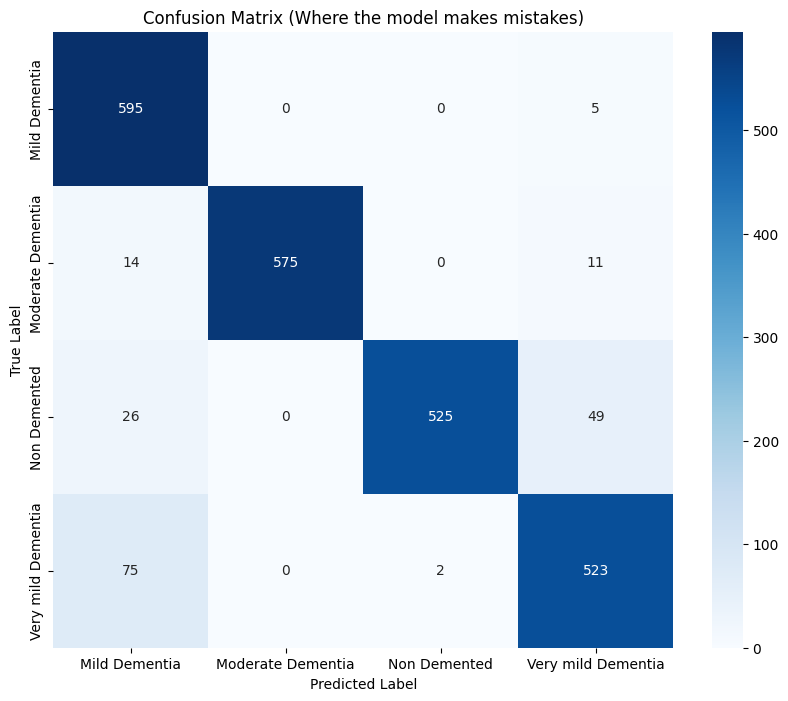


Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia       0.84      0.99      0.91       600
 Moderate Dementia       1.00      0.96      0.98       600
      Non Demented       1.00      0.88      0.93       600
Very mild Dementia       0.89      0.87      0.88       600

          accuracy                           0.92      2400
         macro avg       0.93      0.92      0.92      2400
      weighted avg       0.93      0.92      0.92      2400



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get Predictions
print("Generating predictions for the Confusion Matrix...")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 2. Create Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Where the model makes mistakes)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Print Detailed Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


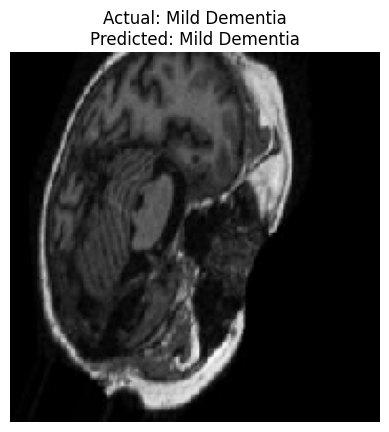

Confidence Scores: [[1.0000000e+00 9.2229732e-25 2.5121086e-17 5.1285689e-15]]
✅ CORRECT PREDICTION


In [10]:
# Pick a random image from the test set
batch = next(iter(test_generator))
img = batch[0][0] # First image in the batch
true_label = np.argmax(batch[1][0]) # First label

# Ask model to predict
pred_probs = model.predict(np.expand_dims(img, axis=0))
pred_label = np.argmax(pred_probs)

# Display
plt.imshow(img)
plt.axis('off')
plt.title(f"Actual: {class_names[true_label]}\nPredicted: {class_names[pred_label]}")
plt.show()

print(f"Confidence Scores: {pred_probs}")
if true_label == pred_label:
    print("✅ CORRECT PREDICTION")
else:
    print("❌ WRONG PREDICTION")